In [12]:
import sinter
from stim_baconshor import *
from sinter_file import *

import stim
import sinter
import pymatching
import numpy as np
import random
from typing import List, Callable, Tuple
import matplotlib.pyplot as plt
from dataclasses import dataclass

from gap_sampler import *


In [2]:
circuit = bacon_shor_circuit(3,0.1)

In [2]:
circuit = bacon_shor_circuit(5,0.1)

In [3]:
print(circuit)

QUBIT_COORDS(0, 0, 0) 0
QUBIT_COORDS(1, 0, 0) 1
QUBIT_COORDS(2, 0, 0) 2
QUBIT_COORDS(0, 1, 0) 3
QUBIT_COORDS(1, 1, 0) 4
QUBIT_COORDS(2, 1, 0) 5
QUBIT_COORDS(0, 2, 0) 6
QUBIT_COORDS(1, 2, 0) 7
QUBIT_COORDS(2, 2, 0) 8
R 0 1 2 3 4 5 6 7 8
TICK
MZZ 0 3 1 4 2 5 3 6 4 7 5 8
MXX 0 1 3 4 6 7 1 2 4 5 7 8
TICK
Y_ERROR(0.1) 0 1 2 3 4 5 6 7 8
Z_ERROR(1e-06) 0 1 2 3 4 5 6 7 8
TICK
MZZ 0 3
DETECTOR(0, 0) rec[-1] rec[-13]
MZZ 1 4
DETECTOR(1, 0) rec[-1] rec[-13]
MZZ 2 5
DETECTOR(2, 0) rec[-1] rec[-13]
MZZ 3 6
DETECTOR(0, 1) rec[-1] rec[-13]
MZZ 4 7
DETECTOR(1, 1) rec[-1] rec[-13]
MZZ 5 8
DETECTOR(2, 1) rec[-1] rec[-13]
MXX 0 1
DETECTOR(0, 0) rec[-1] rec[-13]
MXX 3 4
DETECTOR(0, 1) rec[-1] rec[-13]
MXX 6 7
DETECTOR(0, 2) rec[-1] rec[-13]
MXX 1 2
DETECTOR(1, 0) rec[-1] rec[-13]
MXX 4 5
DETECTOR(1, 1) rec[-1] rec[-13]
MXX 7 8
DETECTOR(1, 2) rec[-1] rec[-13]
TICK
MX 0 3 6
OBSERVABLE_INCLUDE(0) rec[-1] rec[-2] rec[-3]


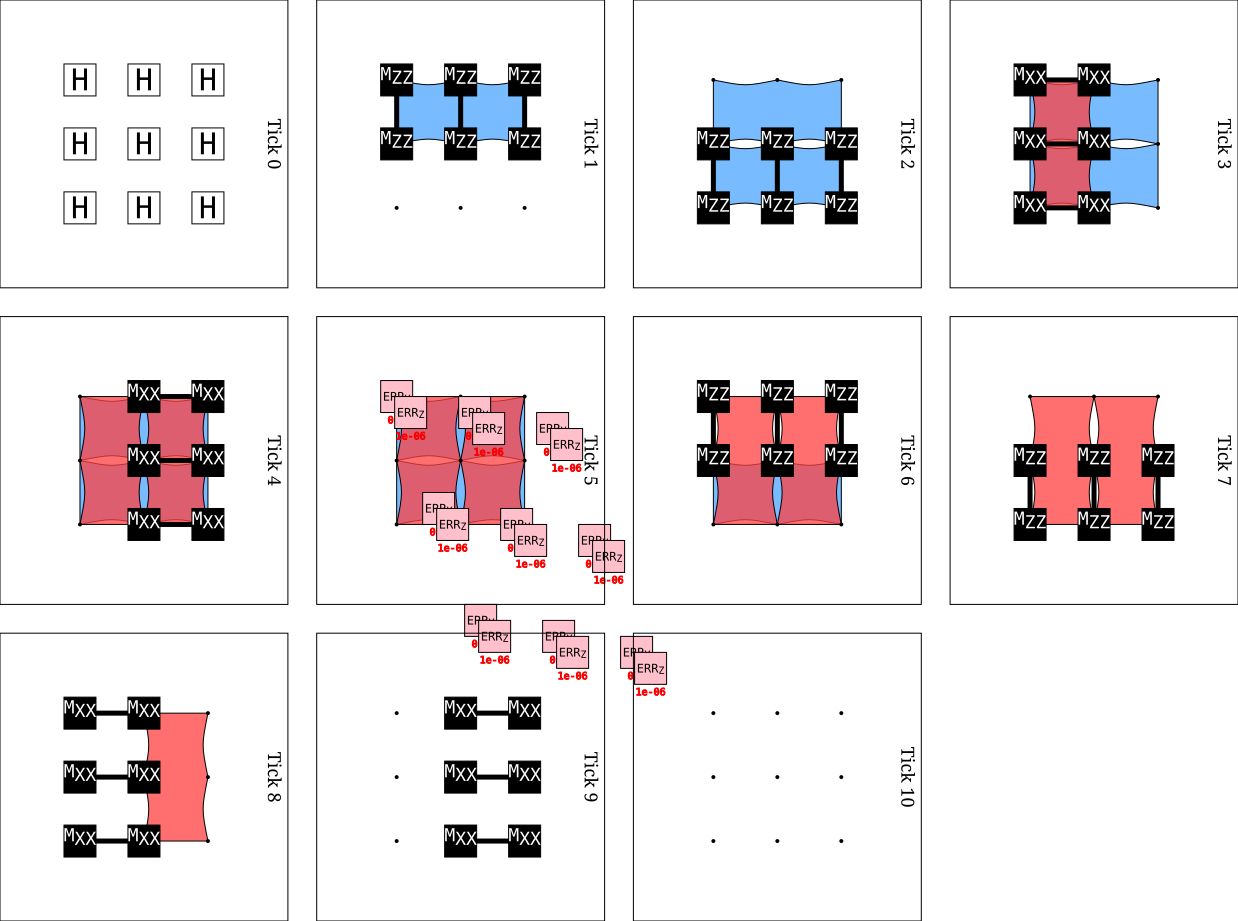

In [3]:
circuit.diagram('detslice-with-ops-svg')

In [5]:
# 1. Define the single task
task = [sinter.Task(
    circuit=bacon_shor_circuit(3,p),
    json_metadata={'d': 3, 'p': p}
) for p in np.arange(0.1, 0.4, 0.1)]

sinter.collect(
        num_workers=1,  # Use 1 worker for simplest debugging
        tasks=task,
        decoders=['pymatching'],
        max_shots=1,
        max_errors=1, # Stop after 10 errors or 100 shots
        print_progress=True,
    )



Starting 1 workers...
3 tasks left:
  workers    decoder eta shots_left errors_left json_metadata            
        1 pymatching   ?          1           1 d=3,p=0.2                
        0 pymatching ?·∞          1           1 d=3,p=0.30000000000000004
        0 pymatching ?·∞          1           1 d=3,p=0.4                
0 tasks left:



[sinter.TaskStats(strong_id='2e23e849a06a385566c6568a64043127252d5d8a972633ae3e913785b25c8b78', decoder='pymatching', json_metadata={'d': 3, 'p': 0.1}, shots=1, seconds=0.00037787482142448425),
 sinter.TaskStats(strong_id='5f592f3c3a2f50e5f3b9e609d7f21292d9b651305ce0e820d4c00f7ea6880e12', decoder='pymatching', json_metadata={'d': 3, 'p': 0.2}, shots=1, seconds=6.620772182941437e-05),
 sinter.TaskStats(strong_id='4c34e78cf125af6de421889174488d86d2f939379a86526b8e0a9087393a41ec', decoder='pymatching', json_metadata={'d': 3, 'p': 0.30000000000000004}, shots=1, errors=1, seconds=8.245930075645447e-05),
 sinter.TaskStats(strong_id='66d1ba217484a6cfb05355840ad362975e989712e80611e1109e7fdbc9600961', decoder='pymatching', json_metadata={'d': 3, 'p': 0.4}, shots=1, seconds=8.979160338640213e-05)]

In [2]:
gs_tasks = [
        sinter.Task(
            circuit=bacon_shor_circuit(3,p),
    json_metadata={'d': 3, 'p': p}
        ) for p in np.arange(0.1, 0.4, 0.1)]
        
# try:    
res = sinter.collect(tasks=gs_tasks, 
                num_workers=1, 
                decoders = ['pymatching-gap'],
                custom_decoders=sinter_samplers(),
                max_shots=80_000,  # Set a reasonable default
                max_errors=10_000 ,   # Set a reasonable default
                #save_resume_filepath ="your_outfile_here.csv"
                )
print(res)
# except Exception as e:
#     print(f"\n*** SINTER FAILED ***")
#     print(f"Error: {e}")

RuntimeError: Worker failed: traceback=Traceback (most recent call last):
  File "/opt/anaconda3/envs/qec_env/lib/python3.11/site-packages/sinter/_collection/_collection_worker_state.py", line 243, in run_message_loop
    num_messages_processed = self.process_messages()
                             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/qec_env/lib/python3.11/site-packages/sinter/_collection/_collection_worker_state.py", line 191, in process_messages
    assert job_key == self.current_task.strong_id()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError


## Plots For Static BS Code

In [ ]:
phys_error_probs = np.logspace(np.log10(1e-4), np.log10(0.1), 20)
samples = run_bacon_shor_simulation(phys_error_probs, )

Starting 12 workers...


Generated 20 tasks.
--- Starting sinter.collect (this may take a while) ---


20 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                        
        1 pymatching   ?  100000000         500 d=3,p=0.0001,rounds=3                
        1 pymatching   ?  100000000         500 d=3,p=0.0001438449888287663,rounds=3 
        1 pymatching   ?  100000000         500 d=3,p=0.00020691380811147902,rounds=3
        1 pymatching   ?  100000000         500 d=3,p=0.00029763514416313193,rounds=3
        1 pymatching   ?  100000000         500 d=3,p=0.00042813323987193956,rounds=3
        1 pymatching   ?  100000000         500 d=3,p=0.0006158482110660267,rounds=3 
        1 pymatching   ?  100000000         500 d=3,p=0.0008858667904100823,rounds=3 
        1 pymatching   ?  100000000         500 d=3,p=0.0012742749857031334,rounds=3 
        1 pymatching   ?  100000000         500 d=3,p=0.0018329807108324356,rounds=3 
        1 pymatching <1m   99955695         495 d=3,p=0.0026366508987303583,rounds=3 
        1 pymatching   ?  100000000    


--- Sinter finished successfully in 7.02s ---


d=3: Measured Slope k = 2.0117 (Expected: 2.0)


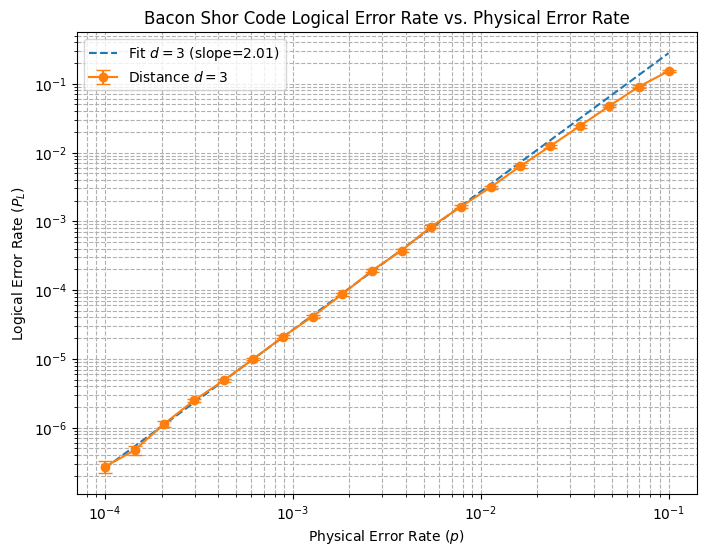

In [3]:
sinter_plot(samples,3, "Bacon Shor Code", errorbars=True)

In [8]:
task = [sinter.Task(
    circuit=bacon_shor_circuit(3,p),
    json_metadata={'d': 3, 'p': p}
) for p in np.arange(0.001, 0.2, 0.01)]

collect = sinter.collect(
        num_workers=1,  # Use 1 worker for simplest debugging
        tasks=task,
        decoders=['pymatching'],
        max_shots=1000,
        max_errors=100, # Stop after 10 errors or 100 shots
        print_progress=True,
    )

Starting 1 workers...
19 tasks left:
  workers    decoder eta shots_left errors_left json_metadata             
        1 pymatching   ?       1000         100 d=3,p=0.011               
        0 pymatching ?·∞       1000         100 d=3,p=0.020999999999999998
        0 pymatching ?·∞       1000         100 d=3,p=0.030999999999999996
        0 pymatching ?·∞       1000         100 d=3,p=0.040999999999999995
        0 pymatching ?·∞       1000         100 d=3,p=0.05099999999999999 
        0 pymatching ?·∞       1000         100 d=3,p=0.06099999999999999 
        0 pymatching ?·∞       1000         100 d=3,p=0.071               
        0 pymatching ?·∞       1000         100 d=3,p=0.08099999999999999 
        0 pymatching ?·∞       1000         100 d=3,p=0.09099999999999998 
        0 pymatching ?·∞       1000         100 d=3,p=0.10099999999999998 
        0 pymatching ?·∞       1000         100 d=3,p=0.11099999999999999 
        0 pymatching ?·∞       1000         100 d=3,p=0.1209999

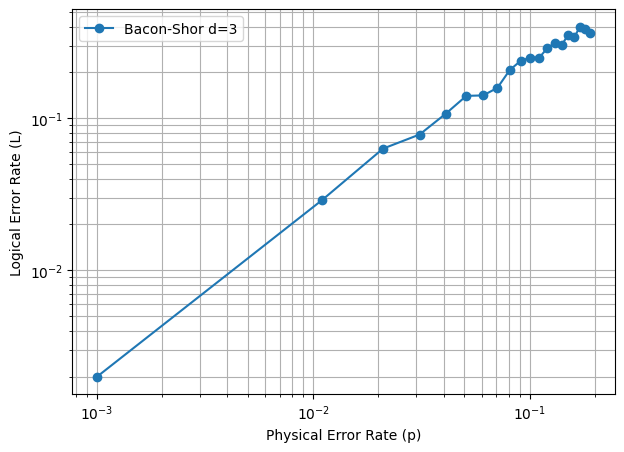

In [9]:
# Extract data
xs = [s.json_metadata['p'] for s in collect]
ys = [s.errors / s.shots for s in collect]

# Sort by p-value so the line connects correctly
sorted_indices = np.argsort(xs)
xs = np.array(xs)[sorted_indices]
ys = np.array(ys)[sorted_indices]

plt.figure(figsize=(7, 5))
plt.plot(xs, ys, 'o-', label="Bacon-Shor d=3")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical Error Rate (p)')
plt.ylabel('Logical Error Rate (L)')
plt.legend()
plt.grid(True, which="both")
plt.show()

In [24]:
def run_simulation(phys_errors, shots=10000):
    logical_errors = []
    for p in phys_errors:
        circuit = bacon_shor_circuit(3, p) 
        
        model = circuit.detector_error_model(decompose_errors=True)
        
        matching_corr = pymatching.Matching.from_detector_error_model(model, enable_correlations=True)
        
        sampler = circuit.compile_detector_sampler()
        syndrome, actual_obs = sampler.sample(shots=shots, separate_observables=True)
        

        predictions = matching_corr.decode_batch(syndrome, enable_correlations=True)
        
        num_err = np.sum(np.any(predictions != actual_obs, axis=1))
        logical_errors.append(num_err / shots)
        print(f"p={p:.1e} | L={num_err/shots:.4e}")
        
    return np.array(logical_errors)

In [25]:
# Assuming you ran: results = run_correlated_simulation(phys_error_probs)
phys_error_probs = np.logspace(np.log10(0.000001), np.log10(0.1), 20)
results = run_simulation(phys_error_probs)
log_p = np.log10(phys_error_probs)
log_L = np.log10(results)
slope, _ = np.polyfit(log_p[results > 0], log_L[results > 0], 1)

print(f"Bacon-Shor d=3 Correlated Slope: {slope:.2f}")

ValueError: Encountered a decomposed error instruction with an undetectable component (0 detectors). This is not supported.

In [2]:
circ = bacon_shor_circuit(3,0.1)

In [3]:
circ

stim.Circuit('''
    QUBIT_COORDS(0, 0, 0) 0
    QUBIT_COORDS(1, 0, 0) 1
    QUBIT_COORDS(2, 0, 0) 2
    QUBIT_COORDS(0, 1, 0) 3
    QUBIT_COORDS(1, 1, 0) 4
    QUBIT_COORDS(2, 1, 0) 5
    QUBIT_COORDS(0, 2, 0) 6
    QUBIT_COORDS(1, 2, 0) 7
    QUBIT_COORDS(2, 2, 0) 8
    TICK
    MZZ 0 3 1 4 2 5
    TICK
    MZZ 3 6 4 7 5 8
    TICK
    MXX 0 1 3 4 6 7
    TICK
    MXX 1 2 4 5 7 8
    TICK
    Y_ERROR(0.1) 0 1 2 3 4 5 6 7 8
    TICK
    MZZ 0 3 1 4 2 5
    TICK
    DETECTOR(2.5, 1.5, 0) rec[-1] rec[-2] rec[-3] rec[-13] rec[-14] rec[-15]
    MZZ 3 6 4 7 5 8
    TICK
    DETECTOR(2.5, 1.5, 0) rec[-1] rec[-2] rec[-3] rec[-13] rec[-14] rec[-15]
    MXX 0 1 3 4 6 7
    TICK
    DETECTOR(0.5, 1.5, 0) rec[-1] rec[-2] rec[-3] rec[-13] rec[-14] rec[-15]
    MXX 1 2 4 5 7 8
    TICK
    DETECTOR(1.5, 1.5, 0) rec[-1] rec[-2] rec[-3] rec[-13] rec[-14] rec[-15]
    OBSERVABLE_INCLUDE(0) Z0 Z1 Z2
''')

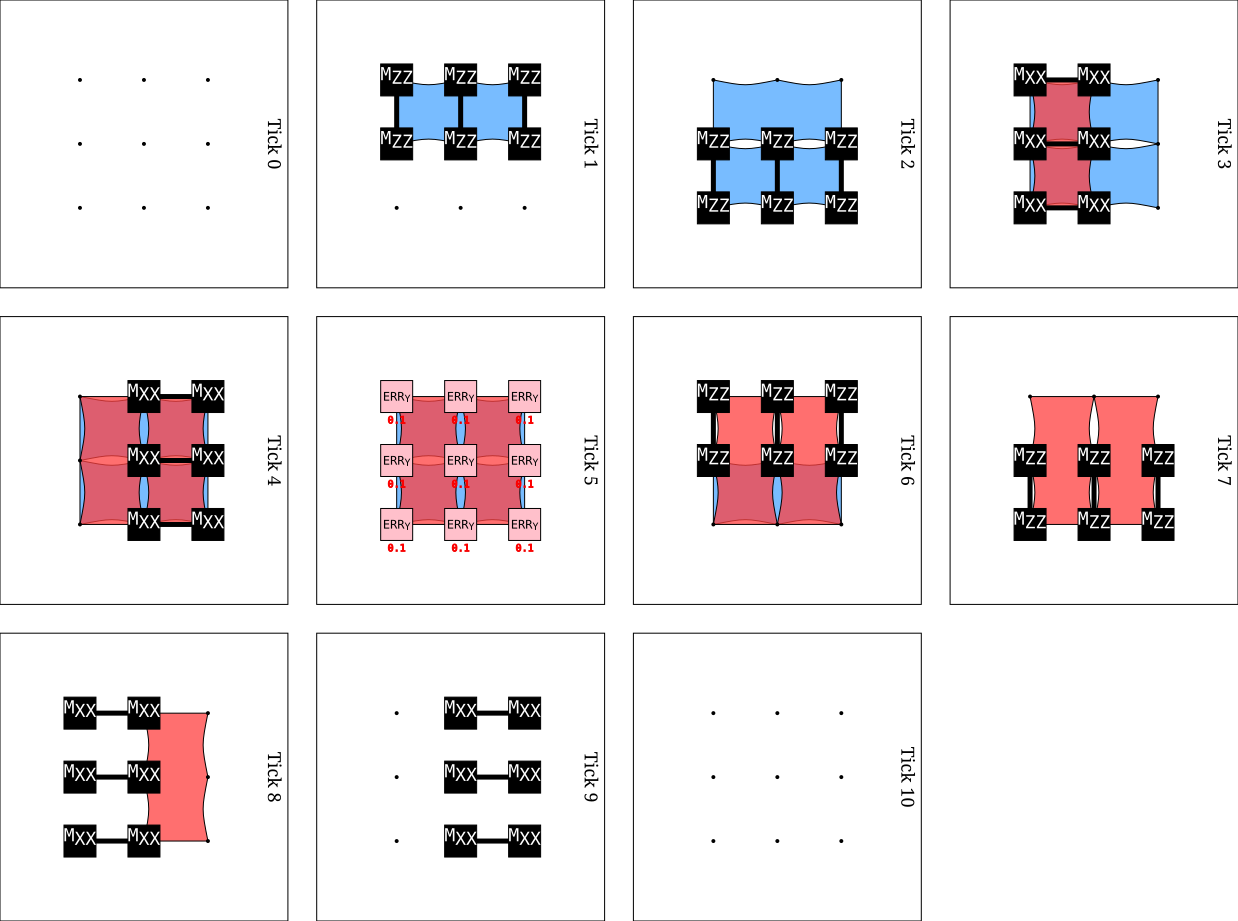

In [10]:
circ.diagram('detslice-with-ops-svg')

In [9]:
circ.detector_error_model()

stim.DetectorErrorModel('''
    error(0.1) D0 D1 D2
    error(0.1) D0 D1 D2 D3
    error(0.1) D0 D1 D3
    error(0.1) D0 D2 D3 L0
    error(0.1) D0 D2 L0
    error(0.1) D0 D3 L0
    error(0.1) D1 D2
    error(0.1) D1 D2 D3
    error(0.1) D1 D3
    detector(2.5, 1.5, 0) D0
    detector(2.5, 1.5, 0) D1
    detector(0.5, 1.5, 0) D2
    detector(1.5, 1.5, 0) D3
''')

In [11]:
circ.detector_error_model(decompose_errors=True)

stim.DetectorErrorModel('''
    error(0.1) D0 D2 L0
    error(0.1) D0 D2 L0 ^ D1 D3 ^ L0
    error(0.1) D0 D2 L0 ^ D1 L0
    error(0.1) D0 D2 L0 ^ D3
    error(0.1) D0 D3 L0
    error(0.1) D0 D3 L0 ^ D1 L0
    error(0.1) D1 D2
    error(0.1) D1 D2 ^ D3
    error(0.1) D1 D3
    detector(2.5, 1.5, 0) D0
    detector(2.5, 1.5, 0) D1
    detector(0.5, 1.5, 0) D2
    detector(1.5, 1.5, 0) D3
''')